# 02. EDA and Data Quality

## 1. Purpose of Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the structure, distributions, relationships, and data-quality characteristics of the training data before preprocessing and model development.

The analysis focuses on identifying useful patterns, unusual observations, missing-data patterns, and potential issues that may affect regression models.

## 2. Import Required Libraries

The required Python libraries are imported for data manipulation, numerical analysis, visualization, and project file handling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

## 3. Load the Raw Dataset and Training Indices

The raw dataset and the previously saved training indices are loaded to reconstruct the exact training dataset used for EDA.

In [2]:
project_root = Path.cwd().parent

data_path = project_root / "data" / "raw" / "melb_data.csv"
train_index_path = project_root / "data" / "processed" / "train_indices.csv"

df = pd.read_csv(data_path)
train_indices = pd.read_csv(train_index_path)["row_index"]

train_df = df.loc[train_indices].copy()

print("Full dataset:", df.shape)
print("Training dataset:", train_df.shape)

Full dataset: (13580, 21)
Training dataset: (10864, 21)


### Observation

The raw dataset contains 13,580 rows and 21 columns. Using the saved training indices successfully reconstructed the training dataset with 10,864 rows and 21 columns. The same fixed training split will be used throughout the EDA process.

## 4. Inspect the Training Data Structure

The training dataset is inspected for its columns, data types, and non-null counts before detailed exploratory analysis.

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10864 entries, 12796 to 7270
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         10864 non-null  object 
 1   Address        10864 non-null  object 
 2   Rooms          10864 non-null  int64  
 3   Type           10864 non-null  object 
 4   Price          10864 non-null  float64
 5   Method         10864 non-null  object 
 6   SellerG        10864 non-null  object 
 7   Date           10864 non-null  object 
 8   Distance       10864 non-null  float64
 9   Postcode       10864 non-null  float64
 10  Bedroom2       10864 non-null  float64
 11  Bathroom       10864 non-null  float64
 12  Car            10814 non-null  float64
 13  Landsize       10864 non-null  float64
 14  BuildingArea   5735 non-null   float64
 15  YearBuilt      6578 non-null   float64
 16  CouncilArea    9774 non-null   object 
 17  Lattitude      10864 non-null  float64
 18  Longtitu

### Observation

The reconstructed training dataset contains 10,864 rows and 21 columns, including 12 `float64`, 1 `int64`, and 8 `object` columns. Missing values remain in `Car`, `BuildingArea`, `YearBuilt`, and `CouncilArea`, with `BuildingArea` and `YearBuilt` having substantial missingness. The non-sequential index values are expected because the training set was created using a randomized split while preserving the original dataset indices.

## 5. Identify Numerical and Categorical Features

Numerical and categorical features require different exploratory analysis. Numerical variables will be examined through distributions, skewness, outliers, and relationships, while categorical variables will be examined through category frequencies and cardinality.

In [4]:
numerical_features = train_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = train_df.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']

Categorical features:
['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea', 'Regionname']


### Observation

The training dataset contains 13 numerical columns and 8 object columns based on their current data types. `Price` is included among the numerical columns but represents the target variable rather than a predictor. Some columns require semantic consideration: `Postcode` is numerically stored but acts as a location identifier, while `Date` is stored as an object but represents temporal information. Their final treatment will be decided during feature engineering and preprocessing.

## 6. Examine the Target Variable

The distribution and descriptive statistics of `Price` are examined before analysing the predictor variables. This helps identify the target range, central tendency, variability, and possible skewness.

In [5]:
price_summary = train_df["Price"].describe()
price_skewness = train_df["Price"].skew()

print(
    price_summary.to_string(
        float_format=lambda value: f"{value:,.2f}"
    )
)

print(f"\nPrice skewness: {price_skewness:.4f}")

count      10,864.00
mean    1,074,964.93
std       641,554.34
min        85,000.00
25%       650,000.00
50%       905,000.00
75%     1,328,000.00
max     9,000,000.00

Price skewness: 2.2959


### Observation

The training target has a mean price of 1,074,964.93 and a median price of 905,000. The mean being higher than the median indicates that expensive properties are pulling the distribution towards the right. The skewness value of 2.2959 confirms a strongly right-skewed distribution. The maximum price of 9,000,000 is also substantially higher than the third quartile of 1,328,000. The distribution will be visualized before deciding whether a target transformation is appropriate.

## 7. Visualize the Target Distribution

A histogram and box plot are used to examine the shape, concentration, upper tail, and potentially extreme values of the target variable.

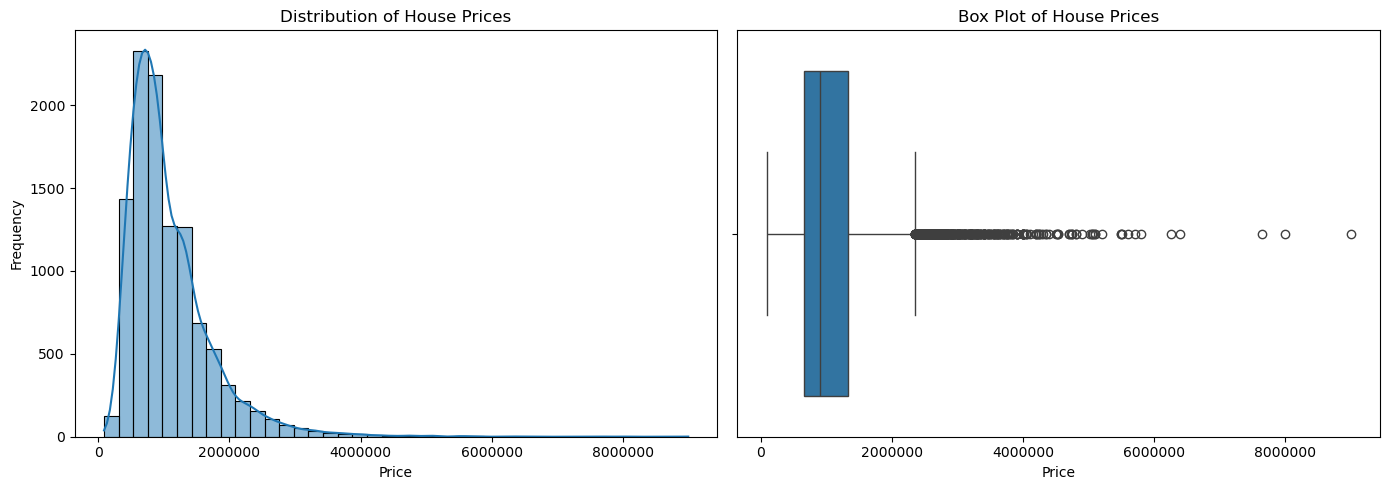

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=train_df,
    x="Price",
    bins=40,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of House Prices")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Frequency")
axes[0].ticklabel_format(style="plain", axis="x")

sns.boxplot(
    data=train_df,
    x="Price",
    ax=axes[1]
)

axes[1].set_title("Box Plot of House Prices")
axes[1].set_xlabel("Price")
axes[1].ticklabel_format(style="plain", axis="x")

plt.tight_layout()
figures_path = project_root / "results" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

plt.savefig(
    figures_path / "price_distribution_and_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


### Observation

The histogram confirms that house prices are strongly right-skewed, with most observations concentrated in the lower and middle price ranges and a long upper tail extending to 9,000,000. The box plot identifies numerous high-price observations beyond the upper whisker. These observations are statistical outliers, but they are not automatically data errors because they may represent genuine luxury properties. They will be quantified and investigated before any treatment decision is made.

## 8. Quantify Potential Target Outliers

The Interquartile Range (IQR) method is used to quantify unusually low or high house prices. Values outside 1.5 times the IQR are treated as potential statistical outliers for investigation, not automatically as data errors.

In [7]:
q1 = train_df["Price"].quantile(0.25)
q3 = train_df["Price"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - (1.5 * iqr)
upper_bound = q3 + (1.5 * iqr)

lower_outliers = (train_df["Price"] < lower_bound).sum()
upper_outliers = (train_df["Price"] > upper_bound).sum()

total_outliers = lower_outliers + upper_outliers
outlier_percentage = (total_outliers / len(train_df)) * 100

print(f"Q1: {q1:,.2f}")
print(f"Q3: {q3:,.2f}")
print(f"IQR: {iqr:,.2f}")
print(f"Lower boundary: {lower_bound:,.2f}")
print(f"Upper boundary: {upper_bound:,.2f}")
print(f"Lower-price potential outliers: {lower_outliers:,}")
print(f"Upper-price potential outliers: {upper_outliers:,}")
print(f"Total potential outliers: {total_outliers:,}")
print(f"Potential outlier percentage: {outlier_percentage:.2f}%")

Q1: 650,000.00
Q3: 1,328,000.00
IQR: 678,000.00
Lower boundary: -367,000.00
Upper boundary: 2,345,000.00
Lower-price potential outliers: 0
Upper-price potential outliers: 496
Total potential outliers: 496
Potential outlier percentage: 4.57%


### Observation

The IQR of house prices is 678,000, producing a lower boundary of -367,000 and an upper boundary of 2,345,000. No observations fall below the lower boundary, while 496 properties exceed the upper boundary. These high-price observations represent 4.57% of the training data. They are potential statistical outliers but are not automatically data errors or influential model observations. They will be investigated further and retained until model residuals and influence diagnostics provide stronger evidence.

## 9. Inspect High-Price Observations

The most expensive properties are inspected using relevant structural and location features. This helps determine whether the high prices appear to represent plausible luxury properties or obvious data-quality problems.

In [8]:
inspection_columns = [
    "Suburb",
    "Rooms",
    "Type",
    "Price",
    "Distance",
    "Bathroom",
    "Landsize",
    "BuildingArea",
    "YearBuilt",
    "Regionname"
]

high_price_properties = (
    train_df.loc[
        train_df["Price"] > upper_bound,
        inspection_columns
    ]
    .sort_values("Price", ascending=False)
)

high_price_properties.head(10)

,Suburb,Rooms,Type,Price,Distance,Bathroom,Landsize,BuildingArea,YearBuilt,Regionname
12094,Mulgrave,3,h,9000000.0,18.8,1.0,744.0,117.0,1960.0,South-Eastern Metropolitan
7692,Canterbury,5,h,8000000.0,9.0,5.0,2079.0,464.3,1880.0,Southern Metropolitan
9575,Hawthorn,4,h,7650000.0,5.3,2.0,1690.0,284.0,1863.0,Southern Metropolitan
12557,Middle Park,5,h,6400000.0,3.0,2.0,553.0,308.0,1920.0,Southern Metropolitan
6372,Toorak,3,h,6250000.0,4.6,3.0,564.0,342.0,2000.0,Southern Metropolitan
7554,Brighton,5,h,5800000.0,11.2,4.0,1276.0,NaN,1880.0,Southern Metropolitan
5631,South Yarra,4,h,5700000.0,3.3,2.0,292.0,272.0,1880.0,Southern Metropolitan
9233,Middle Park,6,h,5600000.0,3.0,4.0,472.0,328.0,1915.0,Southern Metropolitan
9179,Hawthorn,5,h,5510000.0,5.3,2.0,820.0,300.0,1971.0,Southern Metropolitan
12239,Brighton,5,h,5500000.0,10.5,5.0,830.0,NaN,NaN,Southern Metropolitan


### Observation

Most of the highest-priced observations appear potentially plausible because they are houses located mainly in the Southern Metropolitan region and often contain large land areas, building areas, or multiple rooms and bathrooms. Nine of the ten most expensive properties belong to the Southern Metropolitan region, highlighting the possible importance of location. However, the 9,000,000 Mulgrave property appears unusual relative to its visible structural features and requires a within-suburb comparison before determining whether it is a genuine luxury observation or a possible data-quality anomaly. No observations are removed at this stage.

## 10. Investigate the Highest-Priced Property

The highest-priced Mulgrave property is compared with other properties from the same suburb. A within-suburb comparison provides a more meaningful assessment because house prices are strongly affected by location.

In [9]:
mulgrave_columns = [
    "Address",
    "Rooms",
    "Type",
    "Price",
    "Method",
    "Distance",
    "Bedroom2",
    "Bathroom",
    "Car",
    "Landsize",
    "BuildingArea",
    "YearBuilt"
]

mulgrave_properties = (
    train_df.loc[
        train_df["Suburb"] == "Mulgrave",
        mulgrave_columns
    ]
    .sort_values("Price", ascending=False)
)

print("Number of Mulgrave properties:", len(mulgrave_properties))
print(f"Median Mulgrave price: {mulgrave_properties['Price'].median():,.2f}")
print(f"Mean Mulgrave price: {mulgrave_properties['Price'].mean():,.2f}")

mulgrave_properties.head(10)

Number of Mulgrave properties: 26
Median Mulgrave price: 894,500.00
Mean Mulgrave price: 1,251,653.85


,Address,Rooms,Type,Price,Method,Distance,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt
12094,35 Bevis St,3,h,9000000.0,PI,18.8,3.0,1.0,1.0,744.0,117.0,1960.0
9647,10 Adela Ct,4,h,2000000.0,S,18.8,4.0,4.0,2.0,905.0,446.0,NaN
13241,9 Caledonia Cr,3,h,1105000.0,S,18.8,3.0,2.0,2.0,843.0,NaN,NaN
12361,63 Haverbrack Dr,4,h,1105000.0,S,18.8,4.0,3.0,2.0,650.0,224.0,1985.0
12799,1 Sneddon Ct,4,h,1100000.0,S,18.8,4.0,2.0,2.0,748.0,152.0,1996.0
10769,3 Catesby Cl,5,h,1016000.0,SP,18.8,5.0,2.0,2.0,873.0,NaN,NaN
12095,5 Grainger Ct,3,h,1001000.0,S,18.8,3.0,1.0,2.0,727.0,168.0,1970.0
11132,95 Wanda St,4,h,1001000.0,SP,18.8,4.0,2.0,7.0,771.0,NaN,NaN
11448,27 Glencairn St,5,h,960000.0,S,18.8,5.0,2.0,1.0,731.0,130.0,1965.0
13505,2229 Dandenong Rd,3,h,940000.0,S,18.8,3.0,2.0,3.0,709.0,140.0,1958.0


### Observation

Mulgrave contains 26 training properties with a median price of 894,500 and a mean price of 1,251,653.85. The highest-priced property is valued at 9,000,000, which is 4.5 times the second-highest Mulgrave price and approximately 10 times the suburb median. Its visible structural characteristics are also less substantial than those of several lower-priced properties. This makes it a suspected data-quality anomaly, but not a confirmed error. It will remain flagged for further verification rather than being removed automatically.

## 11. Measure the Influence of the Highest Mulgrave Price

A sensitivity calculation compares the mean Mulgrave price with and without its highest-priced observation. This measures how strongly one extreme value affects the arithmetic mean. The original training data is not modified.

In [10]:
highest_price_index = mulgrave_properties["Price"].idxmax()

highest_mulgrave_price = mulgrave_properties.loc[
    highest_price_index,
    "Price"
]

mean_with_highest = mulgrave_properties["Price"].mean()

mean_without_highest = (
    mulgrave_properties
    .drop(index=highest_price_index)["Price"]
    .mean()
)

mean_increase = mean_with_highest - mean_without_highest

percentage_increase = (
    mean_increase / mean_without_highest
) * 100

print(f"Highest Mulgrave price: {highest_mulgrave_price:,.2f}")
print(f"Mean with highest price: {mean_with_highest:,.2f}")
print(f"Mean without highest price: {mean_without_highest:,.2f}")
print(f"Increase in mean: {mean_increase:,.2f}")
print(f"Percentage increase in mean: {percentage_increase:.2f}%")

Highest Mulgrave price: 9,000,000.00
Mean with highest price: 1,251,653.85
Mean without highest price: 941,720.00
Increase in mean: 309,933.85
Percentage increase in mean: 32.91%


### Observation

Including the highest-priced Mulgrave property produces a mean price of 1,251,653.85. Temporarily excluding this observation reduces the mean to 941,720.00, a difference of 309,933.85 or 32.91%. This confirms that the observation strongly influences the suburb-level arithmetic mean. However, sensitivity of the mean does not prove that the recorded price is incorrect or justify automatic removal. The observation will remain flagged for later verification and model-based influence analysis.

### 12.1 Compare Original and Log-Transformed Price Skewness

A temporary log-transformed version of `Price` is created to determine whether the transformation reduces the strong right skewness. The original target column remains unchanged.

In [11]:
log_price = np.log1p(train_df["Price"])

print(f"Original Price skewness: {train_df['Price'].skew():.4f}")
print(f"Log Price skewness: {log_price.skew():.4f}")

Original Price skewness: 2.2959
Log Price skewness: 0.1776


### Observation

The original `Price` distribution has a strong positive skewness of 2.2959. Applying `log1p()` reduces the skewness to 0.1776, representing an approximate reduction of 92.26%. The transformed target is substantially more symmetric, indicating that a log-target model is worth investigating. However, reduced skewness alone does not prove normality or guarantee better predictive performance. Raw-target and log-target models will therefore be compared using training-data cross-validation, with final metrics calculated on the original price scale.

### 12.2 Visual Comparison of Original and Log-Transformed Prices

The original and log-transformed target distributions are visualized side by side. This confirms whether the numerical reduction in skewness is also visible in the distribution shape.

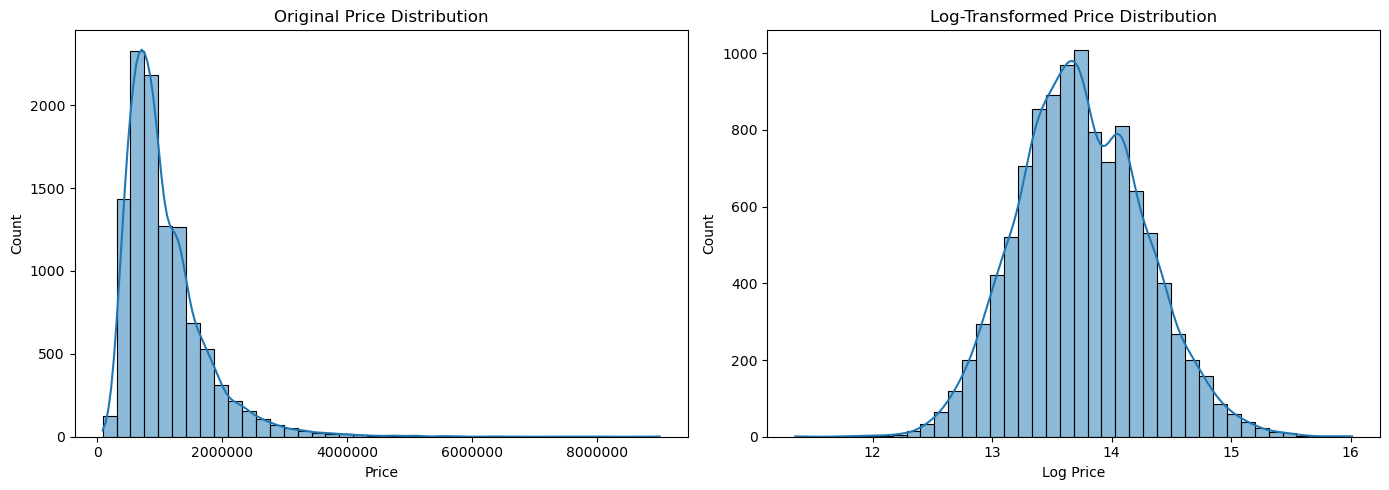

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df["Price"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Original Price Distribution")
axes[0].ticklabel_format(style="plain", axis="x")

sns.histplot(log_price, bins=40, kde=True, ax=axes[1])
axes[1].set_title("Log-Transformed Price Distribution")
axes[1].set_xlabel("Log Price")

plt.tight_layout()

plt.savefig(
    figures_path / "original_vs_log_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

The original target distribution is strongly right-skewed, with most properties concentrated in the lower price range and a long upper tail extending to 9,000,000. After applying `log1p`, the observations become more evenly distributed and the shape becomes approximately symmetric. This visual improvement agrees with the reduction in skewness from 2.2959 to 0.1776. The transformed distribution is not assumed to be perfectly normal, but `log1p(Price)` is retained as a strong modelling candidate. The final choice between raw and log-transformed targets will be based on training cross-validation and evaluation in the original price scale.

### 13.1 Summarize Numerical Predictors

Descriptive statistics are calculated for the numerical predictor variables. This provides an initial view of their valid counts, central values, spread, ranges, and potentially unusual minimum or maximum values.

In [13]:
numerical_predictors = (
    train_df
    .select_dtypes(include="number")
    .columns
    .drop(["Price", "Postcode"])
)

numerical_summary = (
    train_df[numerical_predictors]
    .describe()
    .T
    .round(2)
)

numerical_summary

,count,mean,std,min,25%,50%,75%,max
Rooms,10864.0,2.94,0.96,1.00,2.00,3.0,3.00,10.00
Distance,10864.0,10.10,5.89,0.00,6.10,9.2,13.00,48.10
Bedroom2,10864.0,2.91,0.97,0.00,2.00,3.0,3.00,20.00
Bathroom,10864.0,1.53,0.69,0.00,1.00,1.0,2.00,8.00
Car,10814.0,1.61,0.96,0.00,1.00,2.0,2.00,10.00
Landsize,10864.0,524.16,1380.50,0.00,175.00,435.0,650.25,75100.00
BuildingArea,5735.0,154.00,601.70,0.00,92.00,126.0,175.00,44515.00
YearBuilt,6578.0,1965.10,36.37,1830.00,1940.00,1970.0,2000.00,2018.00
Lattitude,10864.0,-37.81,0.08,-38.18,-37.86,-37.8,-37.76,-37.41
Longtitude,10864.0,144.99,0.10,144.43,144.93,145.0,145.06,145.53


### Observation

The numerical summary reveals several data-quality characteristics. `Car` contains 50 missing values, `BuildingArea` contains 5,129, and `YearBuilt` contains 4,286. Potentially unusual zero values occur in several structural features. Extreme maximum values are present in `Bedroom2`, `Landsize`, and particularly `BuildingArea`, whose maximum of 44,515 is substantially larger than its median of 126. Geographic coordinates and the observed construction-year range appear broadly plausible. These findings require targeted investigation before preprocessing decisions are made.

### 14.1 Quantify Missing Values in the Training Data

Missing-value counts and percentages are calculated using only the training data. The columns are ordered from the highest to the lowest missing percentage to identify the most serious data-completeness issues.

In [14]:
train_missing = pd.DataFrame({
    "Missing Count": train_df.isna().sum(),
    "Missing Percentage": train_df.isna().mean() * 100
})

train_missing = (
    train_missing[train_missing["Missing Count"] > 0]
    .sort_values("Missing Percentage", ascending=False)
)

train_missing.round(2)

,Missing Count,Missing Percentage
BuildingArea,5129,47.21
YearBuilt,4286,39.45
CouncilArea,1090,10.03
Car,50,0.46


### Observation

Four training-data columns contain missing values. `BuildingArea` has the highest missingness at 47.21%, followed by `YearBuilt` at 39.45%. `CouncilArea` has moderate missingness of 10.03%, while `Car` has only 0.46%. Removing all incomplete rows could discard a substantial portion of the training data, while simple imputation may introduce artificial values, particularly for `BuildingArea` and `YearBuilt`. Missingness patterns and their relationship with the target will therefore be investigated before selecting a preprocessing strategy.

### 14.2 Examine Missing-Value Overlap

The overlap between missing `BuildingArea` and `YearBuilt` values is examined. This determines whether both features tend to be unavailable for the same properties or independently across different properties.

In [15]:
building_missing = train_df["BuildingArea"].isna()
year_missing = train_df["YearBuilt"].isna()

print("Both missing:", (building_missing & year_missing).sum())
print("Only BuildingArea missing:", (building_missing & ~year_missing).sum())
print("Only YearBuilt missing:", (~building_missing & year_missing).sum())
print("Neither missing:", (~building_missing & ~year_missing).sum())

Both missing: 4049
Only BuildingArea missing: 1080
Only YearBuilt missing: 237
Neither missing: 5498


### Observation

`BuildingArea` and `YearBuilt` have strongly overlapping missingness. Both values are missing in 4,049 rows, representing 37.27% of the training data. Only `BuildingArea` is missing in 1,080 rows, while only `YearBuilt` is missing in 237 rows. Among rows with missing `YearBuilt`, 94.47% also have missing `BuildingArea`. Overall, 5,366 rows, or 49.39% of the training data, have at least one of these two features missing. This suggests a possible shared data-collection pattern and confirms that deleting incomplete rows would cause substantial data loss.

### 14.3 Compare Prices by Building-Area Availability

Properties are divided into groups based on whether `BuildingArea` is missing or available. Their median prices are compared to determine whether missingness is associated with a different property-price segment.

In [16]:
missing_group = train_df.loc[
    train_df["BuildingArea"].isna(), "Price"
]

available_group = train_df.loc[
    train_df["BuildingArea"].notna(), "Price"
]

print("Missing group count:", len(missing_group))
print(f"Missing group median Price: {missing_group.median():,.2f}")

print("Available group count:", len(available_group))
print(f"Available group median Price: {available_group.median():,.2f}")

Missing group count: 5129
Missing group median Price: 915,000.00
Available group count: 5735
Available group median Price: 900,000.00


### Observation

Properties with missing `BuildingArea` have a median price of 915,000, while properties with an available value have a median price of 900,000. The difference is 15,000, or approximately 1.67% relative to the available group median. This suggests that `BuildingArea` missingness alone does not strongly separate lower- and higher-priced properties. However, this simple comparison does not prove that the missingness is random or that a missing indicator will be unhelpful, because the pattern may also depend on property type, location, or other variables.

### 15.1 Quantify Zero Values

Zero values are counted in selected numerical predictors. Their percentages are calculated using available non-missing observations because a missing value is not equivalent to zero.

In [17]:
zero_features = [
    "Distance", "Bedroom2", "Bathroom",
    "Car", "Landsize", "BuildingArea"
]

zero_counts = (train_df[zero_features] == 0).sum()
available_counts = train_df[zero_features].notna().sum()

zero_summary = pd.DataFrame({
    "Zero Count": zero_counts,
    "Zero Percentage": (zero_counts / available_counts) * 100
})

zero_summary.round(2)

,Zero Count,Zero Percentage
Distance,5,0.05
Bedroom2,12,0.11
Bathroom,25,0.23
Car,828,7.66
Landsize,1568,14.43
BuildingArea,15,0.26


### Observation

Zero values occur most frequently in `Landsize` (14.43%) and `Car` (7.66%), where they may represent properties without separately recorded land or parking. Zero values are rare in `Distance`, `Bedroom2`, `Bathroom`, and `BuildingArea`. While zero distance may represent properties located within the CBD, zero bedrooms, bathrooms, or building area require further investigation. Zero values will not be globally replaced or removed because their validity depends on the feature and property type.

### 15.2 Examine Zero Land Size by Property Type

Zero `Landsize` values are summarized within each property type. Both counts and within-type percentages are calculated to determine whether zero land size is especially common among houses, units, or townhouses.

In [18]:
land_zero_by_type = train_df.groupby("Type")["Landsize"].agg(
    Total="size",
    Zero_Count=lambda values: (values == 0).sum()
)

land_zero_by_type["Zero_Percentage"] = (
    land_zero_by_type["Zero_Count"]
    / land_zero_by_type["Total"]
    * 100
)

land_zero_by_type.round(2)

,Total,Zero_Count,Zero_Percentage
Type,,,
h,7532,138,1.83
t,903,119,13.18
u,2429,1311,53.97


### Observation

Zero land size is strongly associated with property type. Only 1.83% of houses have zero `Landsize`, compared with 13.18% of townhouses and 53.97% of units. Units account for 1,311 of the 1,568 zero-land observations, or approximately 83.61%. This indicates that zero land size frequently represents the structure or recording convention of units rather than a general data error. These values will not be globally replaced, although zero-land houses require further investigation.

### 15.3 Inspect Houses with Zero Land Size

Houses recorded with zero `Landsize` are inspected using their structural, location, and price information. This helps determine whether zero represents a genuine special case, unavailable land information, or a possible data-quality inconsistency.

In [19]:
zero_land_houses = train_df.loc[
    (train_df["Type"] == "h")
    & (train_df["Landsize"] == 0),
    [
        "Suburb", "Address", "Rooms", "Price",
        "Bathroom", "Car", "BuildingArea", "YearBuilt"
    ]
]

print("Zero-land houses:", len(zero_land_houses))

zero_land_houses.head(10)

Zero-land houses: 138


,Suburb,Address,Rooms,Price,Bathroom,Car,BuildingArea,YearBuilt
796,Bentleigh East,38 Edinburgh St,4,1270000.0,2.0,1.0,NaN,NaN
4074,Moonee Ponds,12 Chaucer St,5,2405000.0,2.0,1.0,NaN,NaN
4701,Port Melbourne,171 Bridge St,2,1240000.0,1.0,0.0,NaN,NaN
2522,Fitzroy,3/18 Hanover St,3,1252000.0,2.0,2.0,137.0,2004.0
4292,Niddrie,32 Diamond St,3,1235000.0,2.0,1.0,204.0,2009.0
10020,Reservoir,1 Balfour St,3,630000.0,1.0,2.0,NaN,NaN
6440,Watsonia,17 Longmuir Rd,3,785000.0,1.0,2.0,NaN,NaN
1631,Camberwell,612 Riversdale Rd,4,2750000.0,3.0,1.0,257.0,1912.0
6835,Carlton,99 Neill St,3,1600000.0,3.0,1.0,192.0,NaN
3495,Keilor East,171 Sterling Dr,3,695000.0,1.0,3.0,NaN,NaN


### Observation

There are 138 properties classified as houses (`Type = "h"`) with a recorded `Landsize` of zero. Several of these properties have positive building areas and otherwise plausible structural and price information, so the complete records should not be removed automatically. For houses, a zero land size is unlikely to represent literal physical land and may indicate unavailable land information, subdivision or shared-land arrangements, or a recording inconsistency. Zero land values will therefore not be globally replaced, but zero-land houses will be treated as suspicious cases when defining the preprocessing strategy.

### 15.4 Compare Prices of Houses by Land Availability

The median prices of houses with zero and positive land sizes are compared to investigate whether zero-land houses represent a distinct price group. Median price is used because the target distribution contains extreme values.

In [20]:
houses = train_df.loc[train_df["Type"] == "h"]

zero_land_prices = houses.loc[
    houses["Landsize"] == 0, "Price"
]

positive_land_prices = houses.loc[
    houses["Landsize"] > 0, "Price"
]

print("Zero-land houses:", len(zero_land_prices))
print("Positive-land houses:", len(positive_land_prices))

print(
    "Zero-land median Price:",
    f"{zero_land_prices.median():,.2f}"
)

print(
    "Positive-land median Price:",
    f"{positive_land_prices.median():,.2f}"
)

Zero-land houses: 138
Positive-land houses: 7394
Zero-land median Price: 884,000.00
Positive-land median Price: 1,080,000.00


### Observation

Among the 7,532 houses in the training data, 138 have zero recorded land size and 7,394 have positive land size. The median price of zero-land houses is 884,000, compared with 1,080,000 for positive-land houses, representing an approximately 18.15% lower median. This difference indicates that zero-land houses may form a distinct group, but it does not prove that zero land causes lower prices because location, property size, subdivision status, and data-recording practices may also explain the difference.

The 138 property records will be retained. However, because a house cannot physically have zero land, its zero `Landsize` will be treated as unavailable information during preprocessing. A binary indicator will identify these cases, and the missing land values will be imputed using information learned only from the training data. Zero land values for units and townhouses will remain unchanged because shared or subdivided land is plausible for those property types. This conditional treatment will be validated through training-data cross-validation.


## 16. Distribution of Structural Count Features

The distributions of rooms, bedrooms, bathrooms, and car spaces are examined to identify common property configurations, zero values, and unusually large observations.

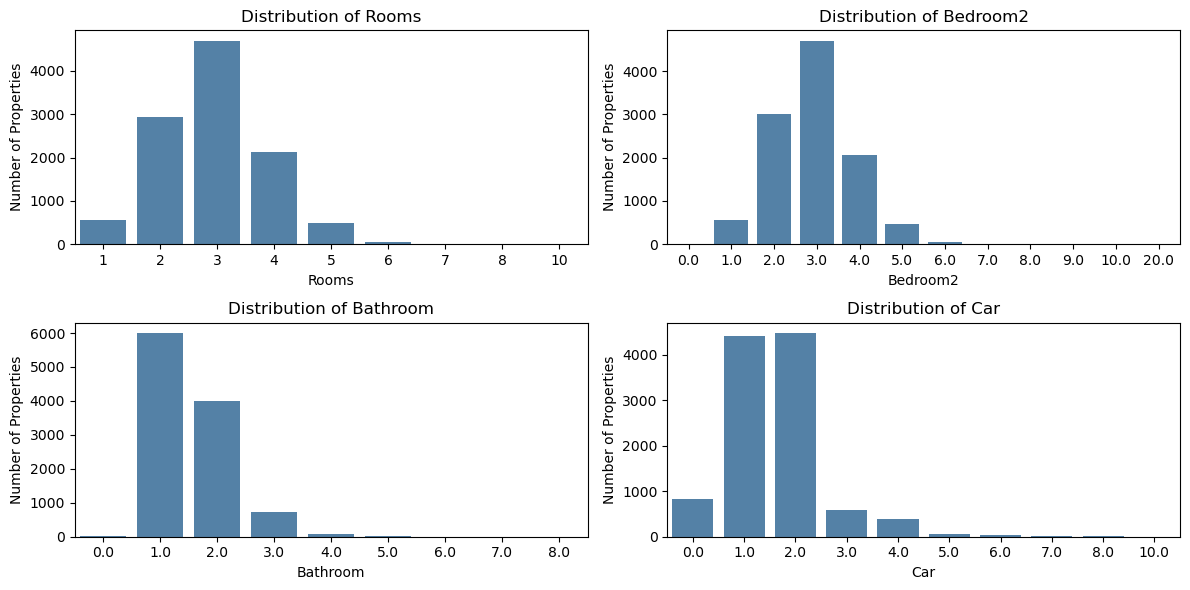

In [21]:
count_features = ["Rooms", "Bedroom2", "Bathroom", "Car"]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for feature, ax in zip(count_features, axes):
    sns.countplot(
        data=train_df,
        x=feature,
        ax=ax,
        color="steelblue"
    )

    ax.set_title(f"Distribution of {feature}")
    ax.set_ylabel("Number of Properties")

plt.tight_layout()

plt.savefig(
    project_root / "results" / "figures" / "structural_count_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
rooms_summary = (
    train_df["Rooms"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

rooms_summary["Percentage"] = (
    rooms_summary["Count"]
    / train_df["Rooms"].notna().sum()
    * 100
).round(2)

rooms_summary

,Count,Percentage
Rooms,,
1,550,5.06
2,2928,26.95
3,4700,43.26
4,2131,19.62
5,489,4.50
6,50,0.46
7,8,0.07
8,7,0.06
10,1,0.01


In [23]:
maximum_rooms = train_df["Rooms"].max()

print("Maximum Rooms:", maximum_rooms)

train_df.loc[
    train_df["Rooms"] == maximum_rooms,
    [
        "Suburb", "Address", "Rooms", "Bedroom2",
        "Bathroom", "Car", "Type", "Price",
        "Landsize", "BuildingArea", "YearBuilt"
    ]
]

Maximum Rooms: 10


,Suburb,Address,Rooms,Bedroom2,Bathroom,Car,Type,Price,Landsize,BuildingArea,YearBuilt
11304,Bundoora,5 Ball Ct,10,10.0,3.0,2.0,h,900000.0,313.0,NaN,2006.0


### Observation

The distribution of `Rooms` is strongly concentrated around typical residential properties. Three-room properties are the most common at 43.26%, while 89.83% of the training properties contain between two and four rooms. Properties with six or more rooms represent only approximately 0.60% of the training data.

The maximum value of 10 rooms occurs in one house. Its alternative bedroom count is also 10, while its bathrooms, car spaces, land size, construction year, and price are plausible. Although the building area is unavailable and the observation is rare, there is insufficient evidence to classify it as an error. The record will be retained and its influence will be assessed during model diagnostics. The similarity between `Rooms` and `Bedroom2` will also be investigated later for possible multicollinearity.

### 16.2 Distribution of Bedroom Count

The distribution of `Bedroom2` is examined to identify common bedroom counts, zero values, and unusually large observations. These values are inspected before making any preprocessing decision.

In [24]:
bedroom2_summary = (
    train_df["Bedroom2"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

bedroom2_summary["Percentage"] = (
    bedroom2_summary["Count"]
    / train_df["Bedroom2"].notna().sum()
    * 100
).round(2)

print(
    "Missing Bedroom2 values:",
    train_df["Bedroom2"].isna().sum()
)

bedroom2_summary

Missing Bedroom2 values: 0


,Count,Percentage
Bedroom2,,
0.0,12,0.11
1.0,557,5.13
2.0,3001,27.62
3.0,4710,43.35
4.0,2060,18.96
5.0,459,4.22
6.0,50,0.46
7.0,6,0.06
8.0,5,0.05


#### 16.2.1 Inspect Zero-Bedroom Properties

Properties with a recorded `Bedroom2` value of zero are inspected using their property type, room count, bathrooms, size, and price. This helps determine whether zero is a plausible value or a possible data-quality issue.

zero_bedroom_properties = train_df.loc[
    train_df["Bedroom2"] == 0,
    [
        "Suburb", "Address", "Type",
        "Rooms", "Bedroom2", "Bathroom",
        "Car", "Price", "Landsize",
        "BuildingArea", "YearBuilt"
    ]
].sort_values(["Type", "Rooms"])

print(
    "Zero-bedroom properties:",
    len(zero_bedroom_properties)
)

zero_bedroom_properties

##### Observation

All 12 properties with `Bedroom2 = 0` contain between two and four recorded rooms. These observations include nine houses, one townhouse, and two units, all with valid positive sale prices. Several rows also contain zero values in other structural fields or missing building information, indicating possible incomplete property records rather than genuine zero-bedroom homes.

Therefore, zero values in `Bedroom2` will be treated as missing information during preprocessing. The complete property rows will be retained, and the missing bedroom values will be imputed using a statistic learned only from the training data. `Rooms` will not be copied directly into `Bedroom2` because the two variables are related but are not guaranteed to have identical definitions.

#### 16.2.2 Inspect the Maximum Bedroom Count

The property with the maximum `Bedroom2` value is inspected using its room count, structural characteristics, property type, location, and price. This helps determine whether the extreme bedroom count is plausible or a possible data-entry error.

In [26]:
maximum_bedrooms = train_df["Bedroom2"].max()

print(
    "Maximum Bedroom2:",
    maximum_bedrooms
)

train_df.loc[
    train_df["Bedroom2"] == maximum_bedrooms,
    [
        "Suburb", "Address", "Type",
        "Rooms", "Bedroom2", "Bathroom",
        "Car", "Price", "Distance",
        "Landsize", "BuildingArea",
        "YearBuilt", "Regionname"
    ]
]

Maximum Bedroom2: 20.0


,Suburb,Address,Type,Rooms,Bedroom2,Bathroom,Car,Price,Distance,Landsize,BuildingArea,YearBuilt,Regionname
7404,Caulfield East,5 Grange Rd,h,3,20.0,1.0,2.0,1650000.0,9.3,875.0,NaN,NaN,Southern Metropolitan


##### Observation

The maximum `Bedroom2` value of 20 belongs to a three-room house with one bathroom and two car spaces. Although the property has a relatively large land size and a valid sale price, its remaining structural information does not support a literal count of 20 bedrooms. Building area and construction year are also unavailable, preventing complete verification.

The value of 20 is therefore considered a highly implausible bedroom record and will be treated as missing during preprocessing. The property row will be retained, and the invalid bedroom value will be imputed using information learned only from the training data. It will not be replaced directly with the `Rooms` value because the two variables are related but not guaranteed to have identical definitions.

### 16.3 Distribution of Bathrooms

The distribution of `Bathroom` is examined to identify common bathroom counts, zero values, and unusually large observations before defining any preprocessing treatment.

In [27]:
bathroom_summary = (
    train_df["Bathroom"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

bathroom_summary["Percentage"] = (
    bathroom_summary["Count"]
    / train_df["Bathroom"].notna().sum()
    * 100
).round(2)

print(
    "Missing Bathroom values:",
    train_df["Bathroom"].isna().sum()
)

bathroom_summary

Missing Bathroom values: 0


,Count,Percentage
Bathroom,,
0.0,25,0.23
1.0,6000,55.23
2.0,3994,36.76
3.0,731,6.73
4.0,87,0.80
5.0,20,0.18
6.0,4,0.04
7.0,1,0.01
8.0,2,0.02


#### 16.3.1 Inspect Zero-Bathroom Properties

Properties with a recorded `Bathroom` value of zero are inspected using their property type, room counts, size, and price. This helps determine whether zero is a plausible value or represents unavailable structural information.

In [28]:
zero_bathroom_properties = train_df.loc[
    train_df["Bathroom"] == 0,
    [
        "Suburb", "Address", "Type",
        "Rooms", "Bedroom2", "Bathroom",
        "Car", "Price", "Landsize",
        "BuildingArea", "YearBuilt"
    ]
].sort_values(["Type", "Rooms"])

print(
    "Zero-bathroom properties:",
    len(zero_bathroom_properties)
)

zero_bathroom_properties

Zero-bathroom properties: 25


,Suburb,Address,Type,Rooms,Bedroom2,Bathroom,Car,Price,Landsize,BuildingArea,YearBuilt
3787,Malvern,42 Cressy St,h,2,2.0,0.0,0.0,780000.0,0.0,NaN,NaN
6671,Yarraville,1a Kingston St,h,2,2.0,0.0,0.0,610000.0,94.0,NaN,NaN
584,Balwyn,5 Shrimpton Ct,h,2,2.0,0.0,0.0,1010000.0,1611.0,NaN,NaN
9917,Hawthorn,1/30 Lisson Gr,h,2,0.0,0.0,0.0,1480000.0,241.0,NaN,NaN
10795,Preston,24 Mitchell St,h,3,3.0,0.0,0.0,1150000.0,502.0,NaN,NaN
139,Alphington,6 Naroon Rd,h,3,3.0,0.0,0.0,1485000.0,597.0,NaN,NaN
913,Bentleigh East,579 Warrigal Rd,h,3,0.0,0.0,0.0,700000.0,456.0,NaN,NaN
1063,Brighton,17 New St,h,3,3.0,0.0,0.0,1900000.0,0.0,NaN,NaN
7494,Balwyn North,215 Doncaster Rd,h,3,0.0,0.0,0.0,1670000.0,818.0,NaN,NaN
4880,Preston,19 Malpas St,h,4,3.0,0.0,0.0,1004000.0,650.0,NaN,NaN


##### Observation

The 25 properties with `Bathroom = 0` contain positive room counts and valid sale prices and include houses, townhouses, and units. All 25 records have missing `BuildingArea`, 24 have missing `YearBuilt`, and 24 also record zero car spaces. This shared pattern indicates incomplete structural information rather than genuine residential properties without bathrooms.

Therefore, zero values in `Bathroom` will be treated as missing during preprocessing. The complete property rows will be retained, and the missing bathroom values will be imputed using a statistic learned only from the training data. Zero values in `Car` will be investigated separately because the absence of dedicated parking can be valid.

#### 16.3.2 Inspect Properties with the Highest Bathroom Counts

Properties containing seven or more bathrooms are inspected using their room counts, size, type, location, and price. This helps determine whether the rare bathroom values are plausible luxury-property characteristics or possible data errors.

high_bathroom_properties = train_df.loc[
    train_df["Bathroom"] >= 7,
    [
        "Suburb", "Address", "Type",
        "Rooms", "Bedroom2", "Bathroom",
        "Car", "Price", "Distance",
        "Landsize", "BuildingArea",
        "YearBuilt", "Regionname"
    ]
].sort_values("Bathroom", ascending=False)

print(
    "Properties with 7 or more bathrooms:",
    len(high_bathroom_properties)
)

high_bathroom_properties

##### Observation

The three properties containing seven or more bathrooms have structural characteristics that provide reasonable support for their high bathroom counts. One property contains eight rooms, eight bedrooms, and eight bathrooms, while another contains nine recorded bedrooms, eight bathrooms, seven car spaces, and a large land area. The seven-bathroom property also has five bedrooms, six car spaces, and a high sale price.

Although some fields show inconsistencies or missing information, there is insufficient evidence to classify the high bathroom counts themselves as errors. Values from one to eight bathrooms will therefore be retained. Only zero bathroom values will be treated as missing during preprocessing. The influence of rare high bathroom counts will be assessed later through model and residual diagnostics.

### 16.4 Distribution of Car Spaces

The distribution of `Car` is examined to identify missing values, properties without recorded parking, common parking capacities, and unusually large values before defining a preprocessing strategy.

In [30]:
car_summary = (
    train_df["Car"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

car_summary["Percentage"] = (
    car_summary["Count"]
    / train_df["Car"].notna().sum()
    * 100
).round(2)

print(
    "Missing Car values:",
    train_df["Car"].isna().sum()
)

print(
    "Available Car values:",
    train_df["Car"].notna().sum()
)

car_summary

Missing Car values: 50
Available Car values: 10814


,Count,Percentage
Car,,
0.0,828,7.66
1.0,4407,40.75
2.0,4483,41.46
3.0,583,5.39
4.0,397,3.67
5.0,53,0.49
6.0,48,0.44
7.0,7,0.06
8.0,5,0.05


#### 16.4.1 Investigate Missing Car Values

Properties with missing `Car` values are examined by property type and by their overlap with other missing fields. This helps determine whether parking information is independently missing or part of a broader data-collection pattern.

In [31]:
missing_car_properties = train_df.loc[
    train_df["Car"].isna()
].copy()

print(
    "Properties with missing Car:",
    len(missing_car_properties)
)

print("\nProperty type counts:")
print(
    missing_car_properties["Type"]
    .value_counts()
)

print("\nOther missing values within these rows:")
print(
    missing_car_properties[
        ["BuildingArea", "YearBuilt", "CouncilArea"]
    ]
    .isna()
    .sum()
)

Properties with missing Car: 50

Property type counts:
Type
h    48
u     2
Name: count, dtype: int64

Other missing values within these rows:
BuildingArea    24
YearBuilt       23
CouncilArea     50
dtype: int64


##### Observation

Among the 50 properties with missing `Car` values, 48 are houses and two are units. All 50 records also have missing `CouncilArea`, while 24 have missing `BuildingArea` and 23 have missing `YearBuilt`. This strong overlap suggests that missing parking information may be associated with a broader data-collection pattern rather than occurring independently.

These property records will be retained. Missing `Car` values will be imputed using the median learned within the training pipeline, and a missing-value indicator will preserve information about which values were originally unavailable. Recorded zero car spaces will be investigated separately because the absence of dedicated parking can be genuine.

#### 16.4.2 Analyze Zero Car Spaces by Property Type

The frequency of zero recorded car spaces is compared across houses, townhouses, and units. This helps determine whether zero is a plausible property characteristic or a possible missing-data code.

In [32]:
zero_car_by_type = (
    train_df
    .groupby("Type")["Car"]
    .agg(
        Available_Count="count",
        Zero_Car_Count=lambda values: (values == 0).sum()
    )
)

zero_car_by_type["Zero_Car_Percentage"] = (
    zero_car_by_type["Zero_Car_Count"]
    / zero_car_by_type["Available_Count"]
    * 100
).round(2)

zero_car_by_type

,Available_Count,Zero_Car_Count,Zero_Car_Percentage
Type,,,
h,7484,682,9.11
t,903,10,1.11
u,2427,136,5.60


#### 16.4.3 Investigate Data-Quality Overlap Within Zero-Car Properties

Zero-car properties are examined for zero bathroom and bedroom counts and for missing building, construction-year, and council information. This helps separate plausible no-parking properties from records that may contain incomplete structural information.

In [33]:
zero_car_properties = train_df.loc[
    train_df["Car"] == 0
].copy()

zero_car_overlap = pd.DataFrame(
    {
        "Count": [
            (zero_car_properties["Bathroom"] == 0).sum(),
            (zero_car_properties["Bedroom2"] == 0).sum(),
            zero_car_properties["BuildingArea"].isna().sum(),
            zero_car_properties["YearBuilt"].isna().sum(),
            zero_car_properties["CouncilArea"].isna().sum()
        ]
    },
    index=[
        "Bathroom also zero",
        "Bedroom2 also zero",
        "BuildingArea missing",
        "YearBuilt missing",
        "CouncilArea missing"
    ]
)

zero_car_overlap["Percentage"] = (
    zero_car_overlap["Count"]
    / len(zero_car_properties)
    * 100
).round(2)

print(
    "Zero-car properties:",
    len(zero_car_properties)
)

zero_car_overlap

Zero-car properties: 828


,Count,Percentage
Bathroom also zero,24,2.90
Bedroom2 also zero,4,0.48
BuildingArea missing,439,53.02
YearBuilt missing,374,45.17
CouncilArea missing,41,4.95


##### Observation

Among the 828 properties with zero recorded car spaces, 24 also have zero bathrooms and four have zero bedroom counts. Missing `BuildingArea` and `YearBuilt` are moderately more common in the zero-car group than in the full training data. However, 804 zero-car properties have positive bathroom counts, and missing `CouncilArea` is less common in this group than in the complete training dataset.

This pattern does not support treating all zero car-space values as missing. Recorded `Car = 0` values will therefore be retained as plausible properties without dedicated parking. Actual missing `Car` values will remain a separate case and will be imputed within the training pipeline. A zero-car indicator may be evaluated through training-data cross-validation.